# 03 — SHAP Explanations

For each window pair (A, B), this notebook computes per-replica SHAP attributions on the flagged set F_{A,B}. The explainer used depends on `MODEL_TYPE`:

| MODEL_TYPE  | Explainer                | Properties                                                |
|-------------|--------------------------|-----------------------------------------------------------|
| `xgboost`   | `shap.TreeExplainer`     | deterministic for a fixed fitted tree model; runs on CPU  |
| `mlp_plr`   | `shap.GradientExplainer` | stochastic, approximate; requires GPU                     |
| `logreg`    | not computed             | LR is a transparent reference (raises ValueError if run)  |

## Cat handling

Each replica was trained on a **combined matrix** `[X | encoder.transform(X_cat)]` where `encoder` is now a **shared per-(window, side)** `OrdinalEncoder` (`min_frequency=1/100`) saved by 02 / 02b at `replicas_<side>/encoder.joblib`. Every replica of that side reuses the same encoder, so categorical integer codes are stable across replicas.

For SHAP we reproduce that same combined matrix, sourcing each preprocessing artefact from where 02 / 02b actually saved it:

- **XGBoost**: load the shared per-(window, side) `encoder.joblib` once per side; the encoded combined matrix is therefore identical across all R replicas of that side. The per-replica `model_r{r}.joblib` is the only thing loaded inside the replica loop. TreeSHAP is computed on the resulting `(n, n_num + n_bin + n_cat)` matrix.
- **MLP-PLR**: load both the shared `encoder.joblib` and the shared `one_hot.joblib` once per side, then build the dummy-axis combined matrix `[X | one_hot.transform(encoder.transform(X_cat))]` once per side. Inside the replica loop only the joblib bundle is opened, which contains `{state_dict, arch_config, scaler}` — the per-replica numeric `StandardScaler`. Binaries and one-hot dummies pass through raw 0/1; numerics are scaled per replica because the model was trained that way. After SHAP returns dummy-axis attributions of shape `(n_explained, n_num + n_bin + n_dummies)`, `aggregate_dummy_shap` collapses the dummy block to the per-cat-variable axis (sum) so the saved tensor sits at `(R, n_explained, n_num + n_bin + n_cat)`.

Saved SHAP arrays therefore have shape `(R, n_explained, n_num + n_bin + n_cat)`. The feature ordering is `feature_names['num'] + feature_names['bin'] + feature_names['cat']` — read by notebook 04 directly from `feature_names.json`.

## Output layout (under `data/shap/{MODEL_TYPE}/pair_{pid:02d}/`)

- `shap_A.npy`, `shap_B.npy` — shape `(R, n_explained, p_combined)`, float32. For XGBoost, `n_explained = |F|`; for MLP-PLR, `n_explained` may be a capped SHAP subsample.
- `mlp_shap_subsample_idx.npy` *(MLP-PLR only)* — positions within `flagged_idx` used for MLP-SHAP.
- `expected_values_A.npy`, `expected_values_B.npy` — shape `(R,)`, float32.
- `run_params.json` — explainer configuration fingerprint for stale-output detection. Includes `training_run_params` loaded from the per-pair `run_params.json` written by 02 / 02b, so any training-side schema change auto-invalidates the cached SHAP outputs.
- `shap_stoch_A.npy`, `shap_stoch_B.npy` — shape `(Q, n_explained, p_combined)`, float32, raw multi-run SHAP attributions on the central replica per side. `Q = N_STOCH_RUNS` for stochastic explainers; `Q = 1` for deterministic TreeSHAP.
- `stochasticity.json` — run descriptor, `schema_version = 'stoch_raw_runs_v1'`. Also includes `training_run_params` so the stochasticity diagnostic re-runs whenever 02 / 02b's training schema changes.
- `global_importance_pair00_A.png` — top-20 global importance plot for pair 0.

## Coordinate system note (MLP-PLR)

MLP-PLR models are trained on *partially scaled* features. Numerics are scaled by a **per-replica** `StandardScaler`; binaries and one-hot dummies pass through raw 0/1. SHAP attributions are computed in this input space on the dummy axis and then summed per cat variable (`aggregate_dummy_shap`) before saving — magnitudes can therefore differ across replicas due to the per-replica numeric scaling, but the categorical-feature axis is on the shared one-hot vocabulary fit per (window, side).

Cosine distance and RBO-on-|attribution| rankings (applied by notebook 04) reduce the emphasis on raw magnitude differences, but they do not make the comparison fully independent of per-replica scaling or background choices. The MLP-PLR SHAP results should therefore be interpreted as end-to-end explanation behaviour for the fitted replica pipelines.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json
import joblib
import hashlib
import numpy as np
import pandas as pd
import shap
from pathlib import Path

WORKSPACE = Path('/content/drive/MyDrive/Thesis/Homesite_workspace')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'

# ── Model type — must match the MODEL_TYPE used in notebook 02 / 02b ─────
MODEL_TYPE = 'mlp_plr'   # 'xgboost' | 'mlp_plr'

MODEL_DIR = WORKSPACE / 'data' / 'models' / MODEL_TYPE
SHAP_DIR  = WORKSPACE / 'data' / 'shap'  / MODEL_TYPE
SHAP_DIR.mkdir(parents=True, exist_ok=True)

print(f'SHAP version: {shap.__version__}')
print(f'MODEL_TYPE  : {MODEL_TYPE}')

SHAP version: 0.51.0
MODEL_TYPE  : xgboost


In [12]:
# ── Load processed data ────────────────────────────────────────────────
X_df = pd.read_parquet(PROC_DIR / 'X.parquet')
X    = X_df.values.astype(np.float32)

# Categoricals are stored as raw strings; the per-replica encoder is loaded from each bundle.
X_cat_df = pd.read_parquet(PROC_DIR / 'X_cat.parquet')
X_cat    = np.asarray(X_cat_df, dtype=object)

with open(PROC_DIR / 'feature_names.json') as f:
    feature_names_json = json.load(f)

feature_names_all = feature_names_json['all']            # = num + bin (matches X.parquet columns)
feature_names_num = feature_names_json['num']
feature_names_bin = feature_names_json['bin']
feature_names_cat = feature_names_json['cat']            # raw-string categoricals in X_cat.parquet
feature_names_combined = feature_names_all + feature_names_cat   # full SHAP attribution axis

assert list(X_df.columns)     == feature_names_all, 'X.parquet column order mismatch.'
assert list(X_cat_df.columns) == feature_names_cat, 'X_cat.parquet column order mismatch.'
assert X.shape[0] == X_cat.shape[0], 'X / X_cat row counts inconsistent.'

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R     = config['parameters']['R']
pairs = config['pairs']

n_num     = len(feature_names_num)
n_bin     = len(feature_names_bin)
n_cat     = len(feature_names_cat)
n_num_bin = X.shape[1]                                    # columns in X.parquet
n_combined = n_num_bin + n_cat                            # combined feature dim fed to the model

# Column positions in the combined matrix [X | X_cat_encoded].
num_col_idx          = [X_df.columns.get_loc(c) for c in feature_names_num]
bin_col_idx          = [i for i in range(n_num_bin) if i not in set(num_col_idx)]
cat_col_idx_combined = list(range(n_num_bin, n_num_bin + n_cat))

print(f'X      : {X.shape}  ({n_num} num + {n_bin} bin)')
print(f'X_cat  : {X_cat.shape}  ({n_cat} cat)')
print(f'Combined SHAP feature dim: {n_combined}')
print(f'R={R}, {len(pairs)} pairs')

X      : (260753, 329)  (253 num + 76 bin)
X_cat  : (260753, 23)  (23 cat)
Combined SHAP feature dim: 352
R=2, 4 pairs


## MLP-PLR setup

Only runs when `MODEL_TYPE == 'mlp_plr'`. The `MLPPLR` / `PLREmbedding` classes below must be byte-identical with the copies in `02b_training_replicas_mlp_plr.ipynb`. If 02b's architecture changes, mirror the change here.

In [13]:
if MODEL_TYPE == 'mlp_plr':
    import math
    import torch
    import torch.nn as nn

    assert torch.cuda.is_available(), 'MLP-PLR SHAP requires a GPU runtime.'
    DEVICE = torch.device('cuda')
    print(f'PyTorch : {torch.__version__}')
    print(f'Device  : {torch.cuda.get_device_name(0)}')


    class PLREmbedding(nn.Module):
        """Vectorised PLR embedding for all numeric features at once. (Identical to 02b.)"""

        def __init__(self, n_num_features, k_periodic, sigma_init, d_embedding):
            super().__init__()
            self.n_num_features = n_num_features
            self.k_periodic     = k_periodic
            self.d_embedding    = d_embedding
            self.c = nn.Parameter(torch.randn(n_num_features, k_periodic) * sigma_init)
            self.W = nn.Parameter(torch.empty(n_num_features, 2 * k_periodic, d_embedding))
            self.b = nn.Parameter(torch.zeros(n_num_features, d_embedding))
            nn.init.kaiming_uniform_(self.W, a=math.sqrt(5))

        def forward(self, x_num):
            v  = (2.0 * math.pi) * self.c.unsqueeze(0) * x_num.unsqueeze(-1)
            pe = torch.cat([torch.sin(v), torch.cos(v)], dim=-1)
            out = torch.einsum('bnk,nkd->bnd', pe, self.W) + self.b.unsqueeze(0)
            out = torch.relu(out)
            return out.reshape(out.shape[0], -1)


    class MLPPLR(nn.Module):
        """MLP-PLR with three input groups. (Identical to 02b.)"""

        def __init__(self, n_num_features, n_bin_features, n_dummies,
                     k_periodic, sigma_init, d_embedding,
                     n_layers, hidden_dim, dropout,
                     num_col_idx, bin_col_idx, dummy_col_idx):
            super().__init__()
            self.n_num_features = n_num_features
            self.n_bin_features = n_bin_features
            self.n_dummies      = n_dummies

            self.register_buffer('num_col_idx_buf',   torch.as_tensor(num_col_idx,   dtype=torch.long))
            self.register_buffer('bin_col_idx_buf',   torch.as_tensor(bin_col_idx,   dtype=torch.long))
            self.register_buffer('dummy_col_idx_buf', torch.as_tensor(dummy_col_idx, dtype=torch.long))

            self.plr = PLREmbedding(n_num_features, k_periodic, sigma_init, d_embedding)

            input_dim = n_num_features * d_embedding + n_bin_features + n_dummies
            layers = []
            in_dim = input_dim
            for _ in range(n_layers):
                layers.extend([nn.Linear(in_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout)])
                in_dim = hidden_dim
            self.backbone = nn.Sequential(*layers)
            self.head     = nn.Linear(hidden_dim, 1)

        def forward(self, x):
            x_num     = x.index_select(1, self.num_col_idx_buf)
            x_bin     = x.index_select(1, self.bin_col_idx_buf)
            x_dummies = x.index_select(1, self.dummy_col_idx_buf)
            emb       = self.plr(x_num)
            z         = torch.cat([emb, x_bin, x_dummies], dim=-1)
            h         = self.backbone(z)
            return self.head(h).squeeze(-1)


    class ShapOutputAdapter(nn.Module):
        """Wrap an MLPPLR so its output is 2-D (batch, 1) instead of 1-D (batch,).

        `shap.GradientExplainer` indexes outputs with `outputs[:, idx]` internally,
        which raises `IndexError` on a bare MLPPLR (whose forward ends with .squeeze(-1)).
        """

        def __init__(self, inner):
            super().__init__()
            self.inner = inner

        def forward(self, x):
            return self.inner(x).unsqueeze(-1)


    def load_mlp_plr_replica(bundle_path, device):
        """Load the per-replica joblib bundle written by 02b. Bundle keys:
        `{state_dict, arch_config, scaler}` — only the per-replica numeric
        StandardScaler lives in the bundle now. Returns (model, num_scaler).
        Use `load_mlp_plr_side_artifacts` to pick up the shared per-(window, side)
        encoder and one_hot.
        """
        bundle = joblib.load(bundle_path)
        model  = MLPPLR(**bundle['arch_config'])
        model.load_state_dict(bundle['state_dict'])
        model.to(device).eval()
        return model, bundle['scaler']


    def load_mlp_plr_side_artifacts(side_dir):
        """Load the shared per-(window, side) preprocessing artefacts written by 02b:

        - `encoder.joblib` — `OrdinalEncoder` shared by every replica of this side
        - `one_hot.joblib` — `OneHotEncoder` for nominal categoricals, also shared
                             (same artefact notebook 02 saves)

        Returns (encoder, one_hot).
        """
        encoder = joblib.load(side_dir / 'encoder.joblib')
        one_hot = joblib.load(side_dir / 'one_hot.joblib')
        return encoder, one_hot


    def assemble_combined_matrix(X_part, X_cat_str_part, encoder, one_hot):
        """Encode the cat string slice with `encoder` + `one_hot` and hstack with X.

        Encoder + one_hot are .transform-only here — the shared per-(window, side)
        artefacts were already fit during 02b training. Output trailing axis is the
        one-hot dummy block on the model's native input space; aggregate to the
        per-cat-variable axis after SHAP via `aggregate_dummy_shap`.
        """
        ord_codes = encoder.transform(X_cat_str_part)
        oh        = one_hot.transform(ord_codes).astype(np.float32)
        return np.hstack([X_part, oh])


    def scale_combined_inplace(X_combined, num_scaler):
        """Scale numeric columns in the combined matrix; binaries and one-hot dummies pass through.

        `num_scaler` is per-replica (from the bundle). Dummies are 0/1 — no scaling.
        """
        out = X_combined.copy()
        out[:, num_col_idx] = num_scaler.transform(X_combined[:, num_col_idx])
        return out


    print('MLP-PLR setup complete (classes + helpers defined).')
else:
    print('MODEL_TYPE != mlp_plr — skipping MLP setup cell.')

MODEL_TYPE != mlp_plr — skipping MLP setup cell.


## SHAP computation loop

For each pair and each replica, this cell computes SHAP attributions using the explainer appropriate for `MODEL_TYPE`.

- For `xgboost`, TreeSHAP is computed on the per-replica combined matrix `[X | encoder.transform(X_cat)]` and on the raw margin / log-odds output.
- For `mlp_plr`, GradientExplainer is applied to the pre-sigmoid logit on the per-replica combined matrix, after `scaler` (numerics, per replica) is applied; binary and one-hot dummy columns pass through unchanged. Dummy-level attributions are summed back to the per-cat-variable axis (`aggregate_dummy_shap`) before saving so the output stays on the original `(n_num + n_bin + n_cat)` axis.

Results are saved pair by pair so the loop can resume after a runtime expiry.

In [ ]:
SEED_BASE = 42

# MLP-PLR SHAP runtime settings — included in run_params.json for staleness detection.
MLP_BG_SIZE         = 1000
MLP_SHAP_BATCH_SIZE = 512
MLP_SHAP_NSAMPLES   = 200   # GradientExplainer MC samples per query (default is 200)

# MLP-PLR SHAP subsampling. XGBoost still explains the full flagged set.
# When MLP_SHAP_SUBSAMPLE is True and N_MLP_SHAP_SUBSAMPLE matches LIME's N_LIME_SUBSAMPLE,
# the MLP-SHAP and LIME subsamples are byte-identical for each pair — independently of run order.
MLP_SHAP_SUBSAMPLE   = True
N_MLP_SHAP_SUBSAMPLE = 100


def build_subsample_idx(flagged_local_idx, p_hat_A, p_hat_B, n_subsample, seed):
    """Stratified-by-risk subsample of `flagged_local_idx`.

    Sort flagged instances by max(p_hat_A, p_hat_B) (which is how they were
    flagged), then pick approximately evenly spaced rank positions. Covers the
    full risk range within the flagged set rather than clustering at the top.
    Returns positions *within flagged_local_idx*.

    NOTE: byte-identical with the copy in 03b_lime_explanations. Edit both together.
    """
    rng = np.random.default_rng(seed)
    n_flagged = len(flagged_local_idx)
    if n_subsample >= n_flagged:
        return np.arange(n_flagged, dtype=np.int64)
    score = np.maximum(p_hat_A[flagged_local_idx], p_hat_B[flagged_local_idx])
    rank_order = np.argsort(-score)
    step = n_flagged / n_subsample
    picks = np.array([int(i * step + rng.uniform(0, step))
                      for i in range(n_subsample)], dtype=np.int64)
    picks = np.clip(picks, 0, n_flagged - 1)
    picks = np.unique(picks)
    if len(picks) < n_subsample:
        remaining = np.setdiff1d(np.arange(n_flagged), picks)
        extra = rng.choice(remaining, size=n_subsample - len(picks), replace=False)
        picks = np.concatenate([picks, extra])
    return np.sort(rank_order[picks[:n_subsample]]).astype(np.int64)


def array_sha1(arr):
    """Stable hash for numpy arrays used in run-configuration fingerprints."""
    arr_c = np.ascontiguousarray(arr)
    return hashlib.sha1(arr_c.view(np.uint8)).hexdigest()


def get_dummy_groups(one_hot):
    """Per-cat-variable column index groups in a fitted OneHotEncoder's output.

    Returns a list of length n_cat where entry j is the list of one-hot column
    positions (relative to position 0 of the one-hot block) belonging to
    categorical variable j. Mirrors notebook 02's helper of the same name.
    """
    groups, cursor = [], 0
    for cats in one_hot.categories_:
        n = len(cats)
        groups.append(list(range(cursor, cursor + n)))
        cursor += n
    return groups


def aggregate_dummy_shap(shap_dummy_axis, dummy_groups, n_num_bin):
    """Aggregate dummy-level SHAP attributions to the per-cat-variable axis (sum).

    Input shape: (..., n_num_bin + n_dummies). Output shape: (..., n_num_bin + n_cat)
    with `n_cat = len(dummy_groups)`. Sum is the mathematically correct aggregation
    for additive attributions (SHAP, LIME); the row-sum sanity property is preserved.
    """
    n_cat = len(dummy_groups)
    out_shape = list(shap_dummy_axis.shape)
    out_shape[-1] = n_num_bin + n_cat
    out = np.zeros(out_shape, dtype=shap_dummy_axis.dtype)
    out[..., :n_num_bin] = shap_dummy_axis[..., :n_num_bin]
    for j, group_cols in enumerate(dummy_groups):
        absolute_cols = [n_num_bin + c for c in group_cols]
        out[..., n_num_bin + j] = shap_dummy_axis[..., absolute_cols].sum(axis=-1)
    return out


def load_json_if_exists(path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


def outputs_are_current(required_files, run_params_file, current_params):
    if not all(p.exists() for p in required_files):
        return False
    saved = load_json_if_exists(run_params_file)
    return saved == current_params


def load_training_run_params(pair_dir):
    return load_json_if_exists(pair_dir / 'run_params.json')


def make_shap_run_params(pair_id, pair_dir, flagged_local_idx, n_explained,
                          n_features, subset_within_flagged=None):
    """Full SHAP configuration fingerprint for one pair."""
    if subset_within_flagged is None:
        subset_within_flagged = np.arange(len(flagged_local_idx), dtype=np.int64)

    if MODEL_TYPE == 'xgboost':
        shap_config = {
            'variant':       'TreeExplainer',
            'model_output':  'raw',
            'output_scale':  'raw_margin_log_odds',
            'background':    None,
            'cat_axis':      'aggregated_per_cat_var_sum',
        }
    elif MODEL_TYPE == 'mlp_plr':
        shap_config = {
            'variant':              'GradientExplainer',
            'output_scale':         'pre_sigmoid_logit',
            'background':           'sampled_from_corresponding_training_window',
            'background_size':      int(MLP_BG_SIZE),
            'batch_size':           int(MLP_SHAP_BATCH_SIZE),
            'nsamples':             int(MLP_SHAP_NSAMPLES),
            'bg_seed_convention':   'fixed_per_side_v2',
            'mlp_shap_subsample':   bool(MLP_SHAP_SUBSAMPLE),
            'n_mlp_shap_subsample': int(N_MLP_SHAP_SUBSAMPLE),
            'cat_axis':             'aggregated_per_cat_var_sum',
        }
    else:
        shap_config = {'variant': None}

    return {
        'explainer':                  'shap',
        'model_type':                 MODEL_TYPE,
        'pair_id':                    int(pair_id),
        'R':                          int(R),
        'n_features':                 int(n_features),
        'n_flagged_total':            int(len(flagged_local_idx)),
        'n_explained':                int(n_explained),
        'flagged_idx_sha1':           array_sha1(flagged_local_idx.astype(np.int64)),
        'subset_within_flagged_sha1': array_sha1(subset_within_flagged.astype(np.int64)),
        'shap_version':               str(shap.__version__),
        'training_run_params':        load_training_run_params(pair_dir),
        'shap_config':                shap_config,
    }


print('Helpers defined.')

Helpers defined.


In [15]:
# ═════════════════════════════════════════════════════════════════════════════
# Main SHAP loop
# ═════════════════════════════════════════════════════════════════════════════

if MODEL_TYPE == 'xgboost':
    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'

        shap_A_path = shap_dir / 'shap_A.npy'
        shap_B_path = shap_dir / 'shap_B.npy'

        print(f'\n── Pair {pid:02d} ──────────────────────────────────────────────')
        shap_dir.mkdir(parents=True, exist_ok=True)

        pred_data         = np.load(pair_dir / 'predictions.npz')
        flagged_local_idx = pred_data['flagged_idx']
        idx_eval          = np.array(p['idx_eval'], dtype=np.int64)
        flagged_global_idx = idx_eval[flagged_local_idx]

        # Raw flagged inputs — `X` part and `X_cat` (string) part. The encoder
        # is shared per (window, side), so the encoded combined matrix is identical
        # across all R replicas of a side and is built once outside the replica loop.
        X_flagged_raw     = X[flagged_global_idx]
        X_cat_flagged_raw = X_cat[flagged_global_idx]

        n_flagged = X_flagged_raw.shape[0]
        print(f'  Flagged instances: {n_flagged:,}  Combined feature dim: {n_combined}')

        if n_flagged == 0:
            print('  WARNING: no flagged instances — skipping.')
            continue

        run_params_file  = shap_dir / 'run_params.json'
        required_outputs = [
            shap_A_path, shap_B_path,
            shap_dir / 'expected_values_A.npy',
            shap_dir / 'expected_values_B.npy',
            run_params_file,
        ]

        current_run_params = make_shap_run_params(
            pair_id               = pid,
            pair_dir              = pair_dir,
            flagged_local_idx     = flagged_local_idx,
            n_explained           = n_flagged,
            n_features            = n_combined,
            subset_within_flagged = np.arange(n_flagged, dtype=np.int64),
        )

        if outputs_are_current(required_outputs, run_params_file, current_run_params):
            print(f'Pair {pid:02d}: SHAP outputs current, skipping.')
            continue

        saved = load_json_if_exists(run_params_file)
        if saved is not None:
            changed_keys = [k for k in current_run_params if saved.get(k) != current_run_params[k]]
            print(f'  Existing SHAP outputs are stale; changed keys: {changed_keys}')

        # ── SHAP for replicas of window A ──────────────────────────────────
        # Load shared per-(window, side) encoder + one_hot once; build dummy-axis matrix once.
        encoder_A      = joblib.load(pair_dir / 'replicas_A' / 'encoder.joblib')
        one_hot_A      = joblib.load(pair_dir / 'replicas_A' / 'one_hot.joblib')
        dummy_groups_A = get_dummy_groups(one_hot_A)
        X_combined_A   = np.hstack([
            X_flagged_raw,
            one_hot_A.transform(encoder_A.transform(X_cat_flagged_raw)).astype(np.float32),
        ])

        shap_A = np.zeros((R, n_flagged, n_combined), dtype=np.float32)
        ev_A   = np.zeros(R, dtype=np.float32)
        for r in range(R):
            model = joblib.load(pair_dir / 'replicas_A' / f'model_r{r}.joblib')
            explainer = shap.TreeExplainer(model, model_output='raw')
            vals = explainer.shap_values(X_combined_A)
            if isinstance(vals, list):
                vals = vals[1]
            # Aggregate dummy-level attributions to per-cat-variable axis (sum).
            shap_A[r] = aggregate_dummy_shap(vals.astype(np.float32), dummy_groups_A, n_num_bin)
            raw_ev = explainer.expected_value
            ev_A[r] = np.float32(raw_ev if not isinstance(raw_ev, list) else raw_ev[1])
            print(f'  A replica {r}: SHAP computed  |mean|={np.abs(shap_A[r]).mean():.5f}  base={ev_A[r]:.4f}')

        # ── SHAP for replicas of window B ──────────────────────────────────
        encoder_B      = joblib.load(pair_dir / 'replicas_B' / 'encoder.joblib')
        one_hot_B      = joblib.load(pair_dir / 'replicas_B' / 'one_hot.joblib')
        dummy_groups_B = get_dummy_groups(one_hot_B)
        X_combined_B   = np.hstack([
            X_flagged_raw,
            one_hot_B.transform(encoder_B.transform(X_cat_flagged_raw)).astype(np.float32),
        ])

        shap_B = np.zeros((R, n_flagged, n_combined), dtype=np.float32)
        ev_B   = np.zeros(R, dtype=np.float32)
        for r in range(R):
            model = joblib.load(pair_dir / 'replicas_B' / f'model_r{r}.joblib')
            explainer = shap.TreeExplainer(model, model_output='raw')
            vals = explainer.shap_values(X_combined_B)
            if isinstance(vals, list):
                vals = vals[1]
            shap_B[r] = aggregate_dummy_shap(vals.astype(np.float32), dummy_groups_B, n_num_bin)
            raw_ev = explainer.expected_value
            ev_B[r] = np.float32(raw_ev if not isinstance(raw_ev, list) else raw_ev[1])
            print(f'  B replica {r}: SHAP computed  |mean|={np.abs(shap_B[r]).mean():.5f}  base={ev_B[r]:.4f}')

        # ── Sanity check: SHAP_sum + base ≈ output_margin (replica 0 of A) ──
        model_A0 = joblib.load(pair_dir / 'replicas_A' / 'model_r0.joblib')
        preds_raw = model_A0.predict(X_combined_A, output_margin=True)
        shap_sum  = shap_A[0].sum(axis=1) + ev_A[0]
        max_err   = np.abs(shap_sum - preds_raw).max()
        print(f'  Sanity (A r0): max |SHAP_sum − log_odds| = {max_err:.6f}')
        if max_err > 0.01:
            print('  WARNING: SHAP consistency error too large!')
        else:
            print('  Sanity check passed.')

        np.save(shap_A_path, shap_A)
        np.save(shap_B_path, shap_B)
        np.save(shap_dir / 'expected_values_A.npy', ev_A)
        np.save(shap_dir / 'expected_values_B.npy', ev_B)
        with open(run_params_file, 'w') as f:
            json.dump(current_run_params, f, indent=2)
        print(f'  Saved shap_A {shap_A.shape}, shap_B {shap_B.shape}, expected_values A/B (R={R})')

    print('\n✓ All SHAP values computed.')


elif MODEL_TYPE == 'mlp_plr':
    BG_SIZE    = MLP_BG_SIZE
    BATCH_SIZE = MLP_SHAP_BATCH_SIZE
    NSAMPLES   = MLP_SHAP_NSAMPLES

    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'

        shap_A_path = shap_dir / 'shap_A.npy'
        shap_B_path = shap_dir / 'shap_B.npy'
        subset_path = shap_dir / 'mlp_shap_subsample_idx.npy'

        print(f'\n── Pair {pid:02d} [mlp_plr] ──────────────────────────────────────')
        shap_dir.mkdir(parents=True, exist_ok=True)

        pred_data          = np.load(pair_dir / 'predictions.npz')
        flagged_local_idx  = pred_data['flagged_idx']
        p_hat_A            = pred_data['p_hat_A']
        p_hat_B            = pred_data['p_hat_B']
        idx_A              = np.array(p['idx_A'],    dtype=np.int64)
        idx_B              = np.array(p['idx_B'],    dtype=np.int64)
        idx_eval           = np.array(p['idx_eval'], dtype=np.int64)
        flagged_global_idx = idx_eval[flagged_local_idx]

        if MLP_SHAP_SUBSAMPLE:
            subset_within_flagged = build_subsample_idx(
                flagged_local_idx, p_hat_A, p_hat_B,
                n_subsample = N_MLP_SHAP_SUBSAMPLE,
                seed        = SEED_BASE + pid * 100,
            )
        else:
            subset_within_flagged = np.arange(len(flagged_local_idx), dtype=np.int64)

        X_flagged_full     = X[flagged_global_idx]
        X_cat_flagged_full = X_cat[flagged_global_idx]
        X_flagged_raw      = X_flagged_full[subset_within_flagged]
        X_cat_flagged_raw  = X_cat_flagged_full[subset_within_flagged]

        n_flagged_total = X_flagged_full.shape[0]
        n_explained     = X_flagged_raw.shape[0]
        print(f'  Flagged total: {n_flagged_total:,}  Explained: {n_explained}  Combined feature dim: {n_combined}')

        if n_explained == 0:
            print('  WARNING: no instances to explain — skipping.')
            continue

        run_params_file  = shap_dir / 'run_params.json'
        required_outputs = [
            shap_A_path, shap_B_path,
            shap_dir / 'expected_values_A.npy',
            shap_dir / 'expected_values_B.npy',
            subset_path, run_params_file,
        ]

        current_run_params = make_shap_run_params(
            pair_id               = pid,
            pair_dir              = pair_dir,
            flagged_local_idx     = flagged_local_idx,
            n_explained           = n_explained,
            n_features            = n_combined,
            subset_within_flagged = subset_within_flagged,
        )

        if outputs_are_current(required_outputs, run_params_file, current_run_params):
            print(f'Pair {pid:02d}: SHAP outputs current, skipping.')
            continue

        saved = load_json_if_exists(run_params_file)
        if saved is not None:
            changed_keys = [k for k in current_run_params if saved.get(k) != current_run_params[k]]
            print(f'  Existing SHAP outputs are stale; changed keys: {changed_keys}')

        # Save subsample first so a partial failure still leaves a valid record
        np.save(subset_path, subset_within_flagged)

        shap_A = np.zeros((R, n_explained, n_combined), dtype=np.float32)
        ev_A   = np.zeros(R, dtype=np.float32)
        shap_B = np.zeros((R, n_explained, n_combined), dtype=np.float32)
        ev_B   = np.zeros(R, dtype=np.float32)

        for AB, idx_window, shap_out, ev_out in [
            ('A', idx_A, shap_A, ev_A),
            ('B', idx_B, shap_B, ev_B),
        ]:
            # Static-environment background, fixed across all R replicas (raw rows).
            bg_seed = SEED_BASE + pid * 10_000 + (0 if AB == 'A' else 5_000)
            rng_bg  = np.random.default_rng(bg_seed)
            n_bg    = min(BG_SIZE, len(idx_window))
            idx_bg  = rng_bg.choice(idx_window, size=n_bg, replace=False)
            X_bg_raw     = X[idx_bg]
            X_cat_bg_raw = X_cat[idx_bg]

            # Load the shared per-(window, side) encoder + one_hot once for this side.
            encoder, one_hot = load_mlp_plr_side_artifacts(pair_dir / f'replicas_{AB}')
            dummy_groups     = get_dummy_groups(one_hot)

            # Combined matrices on the dummy axis (model's native input space) are
            # identical across all replicas of this side.
            X_bg_combined = assemble_combined_matrix(X_bg_raw,      X_cat_bg_raw,      encoder, one_hot)
            X_fl_combined = assemble_combined_matrix(X_flagged_raw, X_cat_flagged_raw, encoder, one_hot)

            for r in range(R):
                bundle_path = pair_dir / f'replicas_{AB}' / f'model_r{r}.joblib'
                model, num_scaler = load_mlp_plr_replica(bundle_path, DEVICE)

                # Per-replica numeric scaling; dummies and binaries pass through raw 0/1.
                X_bg_scaled = scale_combined_inplace(X_bg_combined, num_scaler)
                X_fl_scaled = scale_combined_inplace(X_fl_combined, num_scaler)

                bg_t = torch.from_numpy(X_bg_scaled).float().to(DEVICE)
                fl_t = torch.from_numpy(X_fl_scaled).float().to(DEVICE)

                model_shap = ShapOutputAdapter(model).to(DEVICE).eval()
                explainer  = shap.GradientExplainer(model_shap, bg_t)
                shap_batches = []
                for start in range(0, n_explained, BATCH_SIZE):
                    chunk     = fl_t[start:start + BATCH_SIZE]
                    shap_seed = bg_seed + 1 + r * 1000 + start // BATCH_SIZE
                    np.random.seed(shap_seed)
                    torch.manual_seed(shap_seed)
                    torch.cuda.manual_seed_all(shap_seed)
                    vals = explainer.shap_values(chunk, nsamples=NSAMPLES)
                    if isinstance(vals, list):
                        vals = vals[0]
                    if isinstance(vals, np.ndarray) and vals.ndim == 3 and vals.shape[-1] == 1:
                        vals = vals[..., 0]
                    shap_batches.append(vals)
                vals_full = np.concatenate(shap_batches, axis=0).astype(np.float32)
                # Aggregate dummy-level attributions to per-cat-variable axis (sum).
                shap_out[r] = aggregate_dummy_shap(vals_full, dummy_groups, n_num_bin)

                # Diagnostic baseline: mean logit over the (per-replica scaled) background.
                with torch.no_grad():
                    ev_out[r] = float(model(bg_t).mean().item())

                mean_abs = float(np.abs(shap_out[r]).mean())
                print(f'  {AB} replica {r}: SHAP computed  |mean|={mean_abs:.5f}  base={ev_out[r]:.4f}')

                del model, model_shap, explainer, bg_t, fl_t
                torch.cuda.empty_cache()

        np.save(shap_A_path, shap_A)
        np.save(shap_B_path, shap_B)
        np.save(shap_dir / 'expected_values_A.npy', ev_A)
        np.save(shap_dir / 'expected_values_B.npy', ev_B)
        with open(run_params_file, 'w') as f:
            json.dump(current_run_params, f, indent=2)
        print(f'  Saved shap_A {shap_A.shape}, shap_B {shap_B.shape}, expected_values A/B (R={R})')

    print('\n✓ All SHAP values computed.')


elif MODEL_TYPE == 'logreg':
    raise ValueError(
        'SHAP is not computed for logistic regression. LR is treated as a transparent '
        'reference: see notebook 02 for replica coefficients (coef_*_ref.npy with cat dummies '
        'L2-aggregated per cat var) and full-window coefficients (coef_*_full_ref.npy), '
        'and notebook 04 for their use.'
    )

else:
    raise ValueError(f'Unknown MODEL_TYPE: {MODEL_TYPE}')


── Pair 00 ──────────────────────────────────────────────
  Flagged instances: 3,151  Combined feature dim: 352
Pair 00: SHAP outputs current, skipping.

── Pair 01 ──────────────────────────────────────────────
  Flagged instances: 2,791  Combined feature dim: 352
Pair 01: SHAP outputs current, skipping.

── Pair 02 ──────────────────────────────────────────────
  Flagged instances: 2,224  Combined feature dim: 352
Pair 02: SHAP outputs current, skipping.

── Pair 03 ──────────────────────────────────────────────
  Flagged instances: 3,035  Combined feature dim: 352
Pair 03: SHAP outputs current, skipping.

✓ All SHAP values computed.


## SHAP stochasticity diagnostic

For each pair, this cell selects the **central replica per side** (the replica whose predictions on the explained instances sit closest to the replica-averaged prediction), runs the SHAP explainer `N_STOCH_RUNS = 5` times on the same instances holding everything else fixed (model weights, replica, background, hyperparameters, instance set, instance order, feature order, output space), and saves the raw attribution tensors to disk as `shap_stoch_A.npy` / `shap_stoch_B.npy` of shape `(Q, n_explained, p_combined)`. A minimal `stochasticity.json` descriptor records the replica indices, seeds, and run count.

TreeSHAP (XGBoost) is deterministic: a single run is saved (`Q = 1`). The MLP-PLR `GradientExplainer` is stochastic and all `Q = N_STOCH_RUNS` runs are saved. Notebook 04 reads these tensors and computes the `stoch_cos*` / `stoch_rbo*` columns using its own cosine / RBO helpers — no distance computation happens here.

In [16]:
# Fixed diagnostic configuration. Identical across A/B and across notebooks 03 / 03b.
N_STOCH_RUNS         = 5
STOCH_RUN_SEEDS      = [1000, 1001, 1002, 1003, 1004]
STOCH_SCHEMA_VERSION = 'stoch_raw_runs_v1'


def select_central_replica(preds_side, p_hat_side, explained_local_idx):
    """Replica whose predictions on `explained_local_idx` are closest (MSE) to `p_hat`."""
    diffs = preds_side[:, explained_local_idx] - p_hat_side[explained_local_idx][None, :]
    mse   = np.mean(diffs ** 2, axis=1)
    return int(np.argmin(mse))


def stoch_outputs_match_current(stoch_json_path, phi_paths, current_descriptor):
    """True iff on-disk artefacts match `current_descriptor` and shapes line up.

    `training_run_params` is included in the check so any schema change in 02 / 02b
    (encoder scope, cat-scaler scope, bundle layout, ...) auto-invalidates the cached
    stochasticity outputs.
    """
    if not stoch_json_path.exists():
        return False
    if not all(p.exists() for p in phi_paths):
        return False

    try:
        with open(stoch_json_path) as f:
            saved = json.load(f)
    except Exception:
        return False

    keys_to_check = [
        'schema_version', 'n_runs', 'run_seeds', 'replica_selection',
        'replica_A', 'replica_B', 'n_explained', 'n_features',
        'explained_local_idx_sha1', 'is_deterministic_runs',
        'training_run_params',
    ]
    for k in keys_to_check:
        if saved.get(k) != current_descriptor.get(k):
            return False

    expected_q = int(current_descriptor['n_runs'])
    expected_n = int(current_descriptor['n_explained'])
    expected_p = int(current_descriptor['n_features'])
    for path in phi_paths:
        try:
            arr = np.load(path, mmap_mode='r')
        except Exception:
            return False
        if arr.shape != (expected_q, expected_n, expected_p):
            return False
    return True


print('Stochasticity helpers defined.')

Stochasticity helpers defined.


In [17]:
if MODEL_TYPE == 'xgboost':
    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'
        shap_dir.mkdir(parents=True, exist_ok=True)

        print(f'\n── Pair {pid:02d} stochasticity diagnostic ──')

        stoch_path = shap_dir / 'stochasticity.json'
        phi_A_path = shap_dir / 'shap_stoch_A.npy'
        phi_B_path = shap_dir / 'shap_stoch_B.npy'

        pred_data         = np.load(pair_dir / 'predictions.npz')
        idx_eval          = np.array(p['idx_eval'], dtype=np.int64)
        flagged_local_idx = pred_data['flagged_idx']

        # XGBoost SHAP explains the full flagged set.
        explained_local_idx = flagged_local_idx
        n_explained         = len(explained_local_idx)
        if n_explained == 0:
            print('  No instances to explain — skipping diagnostic.')
            continue

        flagged_global_idx = idx_eval[explained_local_idx]
        X_flagged_raw     = X[flagged_global_idx]
        X_cat_flagged_raw = X_cat[flagged_global_idx]

        replica_A = select_central_replica(pred_data['preds_A'], pred_data['p_hat_A'], explained_local_idx)
        replica_B = select_central_replica(pred_data['preds_B'], pred_data['p_hat_B'], explained_local_idx)

        # TreeSHAP is deterministic → descriptor records n_runs=1, empty seeds.
        # `training_run_params` invalidates the cache when 02 retrains with a different schema.
        current_stoch_descriptor = {
            'schema_version':           STOCH_SCHEMA_VERSION,
            'n_runs':                   1,
            'run_seeds':                [],
            'replica_selection':        'central_prediction_on_explained_instances',
            'replica_A':                int(replica_A),
            'replica_B':                int(replica_B),
            'n_explained':              int(n_explained),
            'n_features':               int(n_combined),
            'explained_local_idx_sha1': array_sha1(explained_local_idx.astype(np.int64)),
            'is_deterministic_runs':    True,
            'training_run_params':      load_training_run_params(pair_dir),
        }

        if stoch_outputs_match_current(stoch_path, [phi_A_path, phi_B_path], current_stoch_descriptor):
            print('  Stochasticity outputs current — skipping.')
            continue

        print(f'  Central replicas: A=r{replica_A}, B=r{replica_B}; n_explained={n_explained}')

        for side, r_central, out_path in [
            ('A', replica_A, phi_A_path),
            ('B', replica_B, phi_B_path),
        ]:
            # Load shared per-(window, side) encoder + one_hot once; build dummy-axis matrix.
            encoder      = joblib.load(pair_dir / f'replicas_{side}' / 'encoder.joblib')
            one_hot      = joblib.load(pair_dir / f'replicas_{side}' / 'one_hot.joblib')
            dummy_groups = get_dummy_groups(one_hot)
            X_combined_flagged = np.hstack([
                X_flagged_raw,
                one_hot.transform(encoder.transform(X_cat_flagged_raw)).astype(np.float32),
            ])

            model = joblib.load(pair_dir / f'replicas_{side}' / f'model_r{r_central}.joblib')
            explainer = shap.TreeExplainer(model, model_output='raw')
            vals = explainer.shap_values(X_combined_flagged)
            if isinstance(vals, list):
                vals = vals[1]
            # Aggregate dummy-level attributions to per-cat-variable axis (sum).
            vals_aggr = aggregate_dummy_shap(vals.astype(np.float32), dummy_groups, n_num_bin)
            phi_runs = vals_aggr[None, ...]
            np.save(out_path, phi_runs)
            print(f'  {side}: saved {out_path.name}  shape={phi_runs.shape}  '
                  f'|mean|={float(np.abs(phi_runs).mean()):.5f}')

        with open(stoch_path, 'w') as f:
            json.dump(current_stoch_descriptor, f, indent=2)
        print('  Saved stochasticity.json')

    print('\n✓ Stochasticity diagnostic complete.')


elif MODEL_TYPE == 'mlp_plr':
    BG_SIZE  = MLP_BG_SIZE
    NSAMPLES = MLP_SHAP_NSAMPLES

    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'
        shap_dir.mkdir(parents=True, exist_ok=True)

        print(f'\n── Pair {pid:02d} [mlp_plr] stochasticity diagnostic ──')

        stoch_path = shap_dir / 'stochasticity.json'
        phi_A_path = shap_dir / 'shap_stoch_A.npy'
        phi_B_path = shap_dir / 'shap_stoch_B.npy'

        pred_data         = np.load(pair_dir / 'predictions.npz')
        idx_A             = np.array(p['idx_A'],    dtype=np.int64)
        idx_B             = np.array(p['idx_B'],    dtype=np.int64)
        idx_eval          = np.array(p['idx_eval'], dtype=np.int64)
        flagged_local_idx = pred_data['flagged_idx']

        # Reuse the SAME subsample as the main loop.
        subset_path = shap_dir / 'mlp_shap_subsample_idx.npy'
        if subset_path.exists():
            subset_within_flagged = np.load(subset_path)
        elif MLP_SHAP_SUBSAMPLE:
            subset_within_flagged = build_subsample_idx(
                flagged_local_idx, pred_data['p_hat_A'], pred_data['p_hat_B'],
                n_subsample = N_MLP_SHAP_SUBSAMPLE,
                seed        = SEED_BASE + pid * 100,
            )
        else:
            subset_within_flagged = np.arange(len(flagged_local_idx), dtype=np.int64)

        explained_local_idx = flagged_local_idx[subset_within_flagged]
        flagged_global_idx  = idx_eval[explained_local_idx]
        X_explain_raw       = X[flagged_global_idx]
        X_cat_explain_raw   = X_cat[flagged_global_idx]
        n_explained         = X_explain_raw.shape[0]

        if n_explained == 0:
            print('  No instances to explain — skipping diagnostic.')
            continue

        replica_A = select_central_replica(pred_data['preds_A'], pred_data['p_hat_A'], explained_local_idx)
        replica_B = select_central_replica(pred_data['preds_B'], pred_data['p_hat_B'], explained_local_idx)

        current_stoch_descriptor = {
            'schema_version':           STOCH_SCHEMA_VERSION,
            'n_runs':                   int(N_STOCH_RUNS),
            'run_seeds':                list(STOCH_RUN_SEEDS),
            'replica_selection':        'central_prediction_on_explained_instances',
            'replica_A':                int(replica_A),
            'replica_B':                int(replica_B),
            'n_explained':              int(n_explained),
            'n_features':               int(n_combined),
            'explained_local_idx_sha1': array_sha1(explained_local_idx.astype(np.int64)),
            'is_deterministic_runs':    False,
            'bg_seed_convention':       'fixed_per_side_v2',
            'background_size':          int(BG_SIZE),
            'nsamples':                 int(NSAMPLES),
            'training_run_params':      load_training_run_params(pair_dir),
        }

        if stoch_outputs_match_current(stoch_path, [phi_A_path, phi_B_path], current_stoch_descriptor):
            print('  Stochasticity outputs current — skipping.')
            continue

        print(f'  Central replicas: A=r{replica_A}, B=r{replica_B}; n_explained={n_explained}')

        for side, idx_window, r_central, out_path in [
            ('A', idx_A, replica_A, phi_A_path),
            ('B', idx_B, replica_B, phi_B_path),
        ]:
            # Shared per-(window, side) encoder + one_hot — same as the main loop.
            encoder, one_hot = load_mlp_plr_side_artifacts(pair_dir / f'replicas_{side}')
            dummy_groups     = get_dummy_groups(one_hot)

            model, num_scaler = load_mlp_plr_replica(
                pair_dir / f'replicas_{side}' / f'model_r{r_central}.joblib', DEVICE)

            # Background fixed across all Q runs AND identical to the main-loop bg_seed.
            bg_seed = SEED_BASE + pid * 10_000 + (0 if side == 'A' else 5_000)
            rng_bg  = np.random.default_rng(bg_seed)
            n_bg    = min(BG_SIZE, len(idx_window))
            idx_bg  = rng_bg.choice(idx_window, size=n_bg, replace=False)

            X_bg_combined = assemble_combined_matrix(X[idx_bg],         X_cat[idx_bg],       encoder, one_hot)
            X_fl_combined = assemble_combined_matrix(X_explain_raw,     X_cat_explain_raw,   encoder, one_hot)
            X_bg_scaled   = scale_combined_inplace(X_bg_combined, num_scaler)
            X_fl_scaled   = scale_combined_inplace(X_fl_combined, num_scaler)

            bg_t = torch.from_numpy(X_bg_scaled).float().to(DEVICE)
            fl_t = torch.from_numpy(X_fl_scaled).float().to(DEVICE)

            model_shap = ShapOutputAdapter(model).to(DEVICE).eval()
            explainer  = shap.GradientExplainer(model_shap, bg_t)

            phi_runs = np.zeros((N_STOCH_RUNS, n_explained, n_combined), dtype=np.float32)
            for q, run_seed in enumerate(STOCH_RUN_SEEDS):
                np.random.seed(run_seed)
                torch.manual_seed(run_seed)
                torch.cuda.manual_seed_all(run_seed)
                vals = explainer.shap_values(fl_t, nsamples=NSAMPLES)
                if isinstance(vals, list):
                    vals = vals[0]
                if isinstance(vals, np.ndarray) and vals.ndim == 3 and vals.shape[-1] == 1:
                    vals = vals[..., 0]
                # Aggregate dummy-level attributions to per-cat-variable axis (sum).
                phi_runs[q] = aggregate_dummy_shap(vals.astype(np.float32), dummy_groups, n_num_bin)
                print(f'  {side} run {q+1}/{N_STOCH_RUNS} seed={run_seed} done')

            np.save(out_path, phi_runs)
            print(f'  {side}: saved {out_path.name}  shape={phi_runs.shape}')

            del model, model_shap, explainer, bg_t, fl_t
            torch.cuda.empty_cache()

        with open(stoch_path, 'w') as f:
            json.dump(current_stoch_descriptor, f, indent=2)
        print('  Saved stochasticity.json')

    print('\n✓ Stochasticity diagnostic complete.')


── Pair 00 stochasticity diagnostic ──
  Stochasticity outputs current — skipping.

── Pair 01 stochasticity diagnostic ──
  Stochasticity outputs current — skipping.

── Pair 02 stochasticity diagnostic ──
  Stochasticity outputs current — skipping.

── Pair 03 stochasticity diagnostic ──
  Stochasticity outputs current — skipping.

✓ Stochasticity diagnostic complete.


## Quick SHAP summary (pair 0)

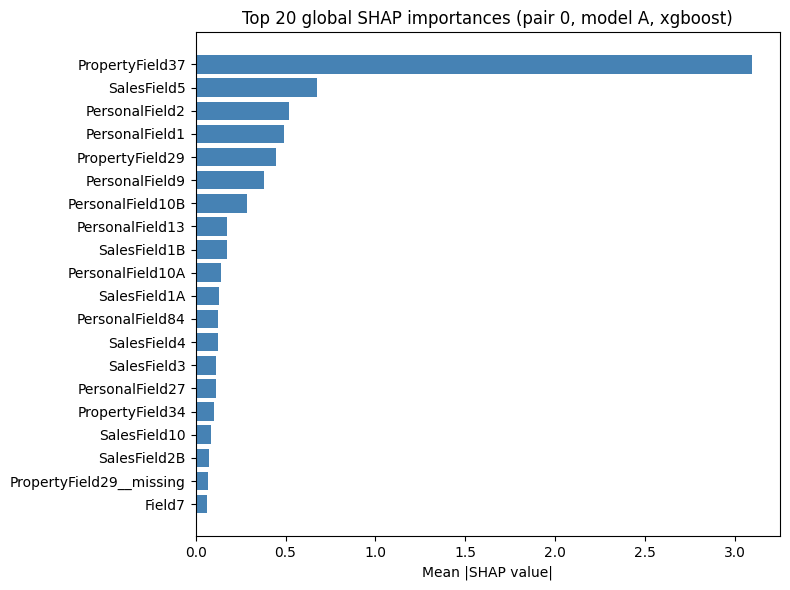

In [18]:
if MODEL_TYPE in ('xgboost', 'mlp_plr'):
    import matplotlib.pyplot as plt

    shap_A_0 = np.load(SHAP_DIR / 'pair_00' / 'shap_A.npy')   # (R, |F|, p)

    # Replica-averaged SHAP for pair 0
    phi_bar_A = shap_A_0.mean(axis=0)   # (|F|, p)

    # Global importance: mean |φ| per feature
    global_imp = np.abs(phi_bar_A).mean(axis=0)
    top_k = 20
    top_idx = np.argsort(global_imp)[::-1][:top_k]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(
        [feature_names_combined[i] for i in top_idx[::-1]],
        global_imp[top_idx[::-1]],
        color='steelblue'
    )
    ax.set_title(f'Top {top_k} global SHAP importances (pair 0, model A, {MODEL_TYPE})')
    ax.set_xlabel('Mean |SHAP value|')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'global_importance_pair00_A.png', dpi=120)
    plt.show()
